# Import libraries

In [87]:
# import libraries
import numpy as np
from numpy import median
from scipy import stats
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter
import random as rn
from functools import reduce

# Import and suppress warnings
import warnings
warnings.filterwarnings('ignore')
import os

# Import cleaned dataset

In [88]:
# Read the file
df2 = pd.read_csv('Clean3.csv')

In [89]:
df2

,Unnamed: 0,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,2,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,7,2,...,1,0,8,0,1,6,4,0,5,1
2,3,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,8,2,...,1,0,8,0,1,6,4,0,5,1
3,4,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,9,2,...,1,0,8,0,1,6,4,0,5,1
4,5,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,10,4,...,3,3,21,2,3,5,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,23199,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,19337,3,...,3,1,19,2,4,1,0,0,0,0
23135,23200,60,Travel_Rarely,370,Research & Development,1,4,Medical,19338,3,...,3,1,19,2,4,1,0,0,0,0
23136,23201,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,19340,3,...,3,1,19,2,4,1,0,0,0,0
23137,23202,60,Travel_Rarely,370,Research & Development,1,4,Medical,19344,3,...,3,1,20,2,3,20,7,2,13,0


In [90]:
df2 = df2.drop(df2.columns[0], axis=1)

In [91]:
df2

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,7,2,Female,...,1,0,8,0,1,6,4,0,5,1
2,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,8,2,Female,...,1,0,8,0,1,6,4,0,5,1
3,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,9,2,Female,...,1,0,8,0,1,6,4,0,5,1
4,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,10,4,Female,...,3,3,21,2,3,5,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,19337,3,Male,...,3,1,19,2,4,1,0,0,0,0
23135,60,Travel_Rarely,370,Research & Development,1,4,Medical,19338,3,Male,...,3,1,19,2,4,1,0,0,0,0
23136,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,19340,3,Male,...,3,1,19,2,4,1,0,0,0,0
23137,60,Travel_Rarely,370,Research & Development,1,4,Medical,19344,3,Male,...,3,1,20,2,3,20,7,2,13,0


In [92]:
df2.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeNumber,int64
EnvironmentSatisfaction,int64
Gender,object


In [93]:
dff = df2.copy()

In [94]:
# Changing object types to categories
cols = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
for col in cols:
    df2[col] = df2[col].astype('category')

In [95]:
df2.dtypes

,0
Age,int64
BusinessTravel,category
DailyRate,int64
Department,category
DistanceFromHome,int64
Education,int64
EducationField,category
EmployeeNumber,int64
EnvironmentSatisfaction,int64
Gender,category


In [96]:
df3 = df2.copy(deep=True)

# Exploratory Data Analysis

**After data cleaning we have 23139 rows(employees data) and 32 features consisting of both categorical as well as the numerical features. Response variable is 'Attrition' of the employees which can 1 and 0 (representing 'Yes' and 'No' respectively). This is what we will predict.**

Target Variable:(Attrition Status)

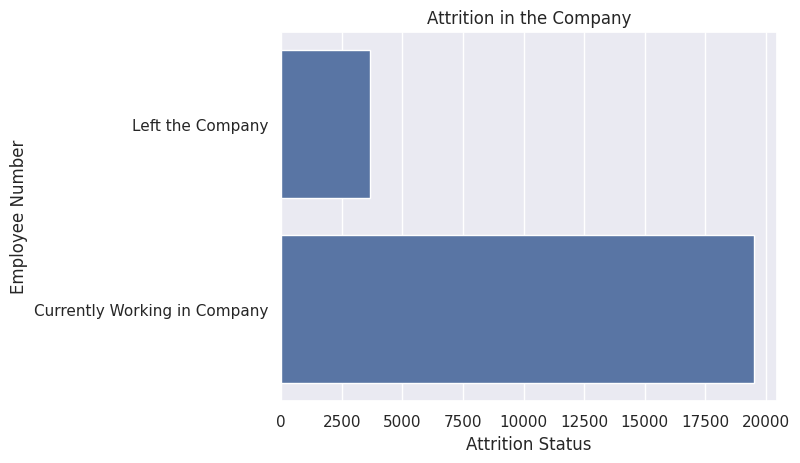

,count
Attrition,
Currently Working in Company,19486
Left the Company,3653


In [97]:
trgt = df2['Attrition'].apply(lambda x: 'Currently Working in Company' if x == 0 else 'Left the Company')
sns.countplot(trgt)
plt.title('Attrition in the Company')
plt.xlabel('Attrition Status')
plt.ylabel('Employee Number')
plt.show()
trgt.value_counts()

### Features:

In [98]:
# Create Feature Dataframe
def table_df(x):
    """
    This function creates dataframe for each feature in the dataset
    """

    feature = df2.groupby(x).agg({'Attrition':['size', 'sum', 'mean']})
    feature.columns = [' '.join(col).strip() for col in feature.columns.values]
    feature = feature.reset_index()
    feature['Attrition mean'] = feature['Attrition mean']*100
    feature.columns = [x, 'Total Employee ', 'Attrition Number',
                       '% of Attrition in the Relevant Group']
    feature['% of Attrition in the Company'] = (feature['Attrition Number'] / 3653)*100

    return feature

In [99]:
# Create graph for each feature to compare its attrition in the company

def graph_df(x, y = 'bar', z = 0):
    """
    This function creates graph for each feature in the dataset
    """

    feature = df2.groupby(x).agg({'Attrition':['size', 'sum', 'mean']})
    feature.columns = [' '.join(col).strip() for col in feature.columns.values]
    feature = feature.reset_index()
    feature['Attrition mean'] = feature['Attrition mean']*100
    feature.columns = [x, 'Total Employee', 'Attrition Number',
                       '% of Attrition in the Relevant Group']

    fig0, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    feature.set_index(feature[x], drop=True, inplace=True)
    feature['Total Employee'].plot(kind = y, stacked = True, ax = ax1,
                                   color='yellow', rot = z)
    feature['% of Attrition in the Relevant Group'].plot(use_index = False,
                                                         kind = 'line', ax = ax2, colormap='Spectral')
    plt.title('Attrition compared to' + " " + x  + " " + "Groups")
    ax1.set_xlabel(x)
    ax1.yaxis.label.set_color('black')
    ax1.set_ylabel("Total Employee")
    ax2.set_ylabel("Attrition Percentage in the Relevant Group")
    ax2.yaxis.label.set_color('black')
    plt.tight_layout()
    plt.show()


**Age**

In [100]:
# Labeling age groups
table_df(x = 'Age')
bins = [17, 21, 25, 35, 60]
group_names = ['(18-21)', '(22-25)', '(26-35)', '(36-60)']
df2['Age'] = pd.cut(df2['Age'], bins, labels = group_names)

In [101]:
# Age Group & Attrition Table
table_df(x = 'Age')

,Age,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,(18-21),639,341,53.364632,9.334793
1,(22-25),1306,349,26.722818,9.553791
2,(26-35),9507,1756,18.470601,48.070079
3,(36-60),11687,1207,10.327715,33.041336


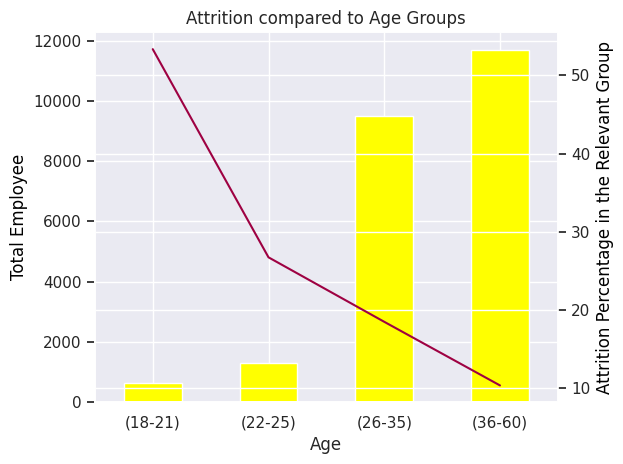

In [102]:
# Attrition Compared to Age Group Graph
graph_df(x = 'Age')

**Business Travel**

In [103]:
# Business Travel & Attrition Table
table_df(x = 'BusinessTravel')

,BusinessTravel,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Non-Travel,2362,187,7.917019,5.119080
1,Travel_Frequently,4367,1080,24.730937,29.564741
2,Travel_Rarely,16410,2386,14.539915,65.316178


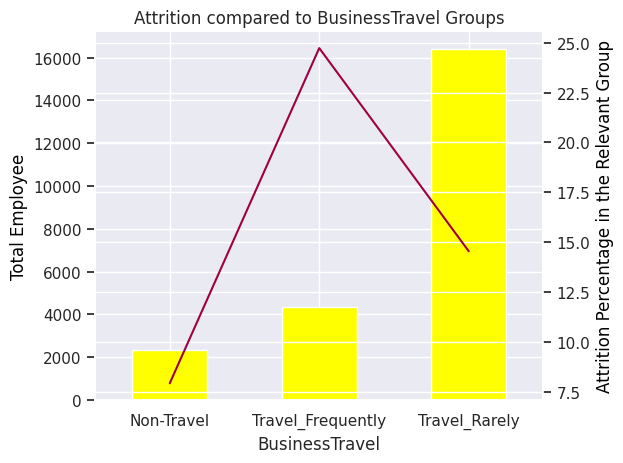

In [104]:
# Attrition compared to Business Travel Group Graph
graph_df(x = 'BusinessTravel')

**Department**

In [105]:
# Department & Attrition Table
table_df(x = 'Department')

,Department,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Human Resources,1003,187,18.644068,5.119080
1,Research & Development,15097,2036,13.486123,55.735012
2,Sales,7039,1430,20.315386,39.145907


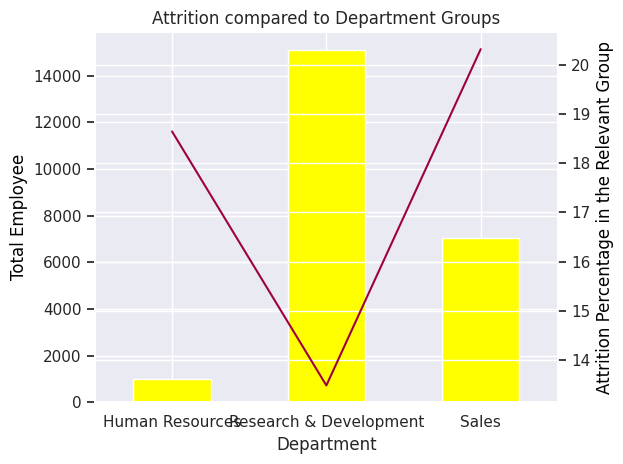

In [106]:
# Attrition compared to Department Graph
graph_df(x = 'Department')

**Distance From Home**

In [107]:
# Labeling Distance From Home Groups
table_df(x = 'DistanceFromHome')
bins = [0, 3, 6, 10, 29]
group_names = ['1-3', '4-6', '7-10', '10+']
df2['DistanceFromHome'] = pd.cut(df2['DistanceFromHome'], bins, labels = group_names)

In [108]:
# Distance From Home Group & Attrition Table
table_df(x = 'DistanceFromHome')

,DistanceFromHome,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,1-3,7904,1078,13.638664,29.509992
1,4-6,2967,406,13.683856,11.114153
2,7-10,5276,763,14.461713,20.886942
3,10+,6992,1406,20.108696,38.488913


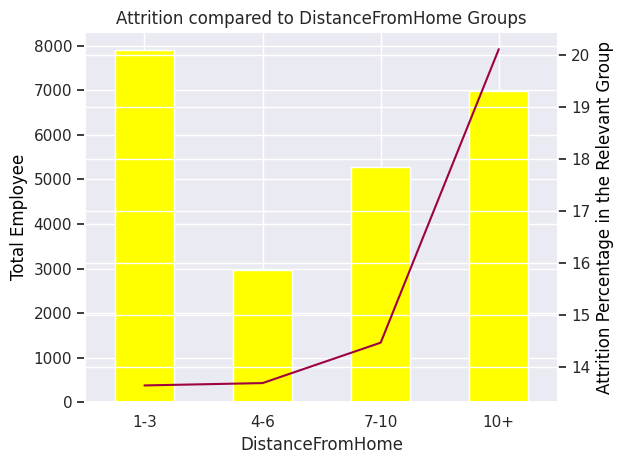

In [109]:
# Attrition compared to Distance From Home Graph
graph_df(x = 'DistanceFromHome')

**Education**

In [110]:
# Labeling education levels
table_df(x = 'Education')
df2['Education'] = df2['Education'].map({1:'Below College', 2:'College',
                                         3:'Bachelor', 4:'Master', 5:'Doctor'})

In [111]:
# Education Level & Attrition Table
table_df(x = 'Education')

,Education,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Bachelor,8984,1503,16.729742,41.144265
1,Below College,2697,496,18.390805,13.577881
2,College,4465,687,15.386338,18.806460
3,Doctor,753,79,10.491368,2.162606
4,Master,6240,888,14.230769,24.308787


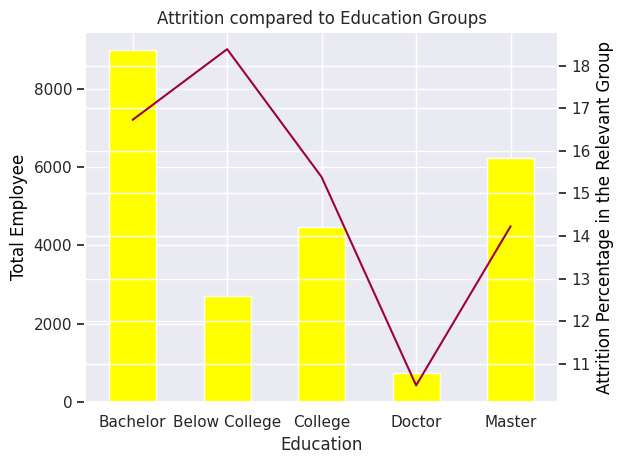

In [112]:
# Attrition compared to Education Level Graph
graph_df(x = 'Education')

**Education Field**

In [113]:
# Education Field & Attrition Table
table_df(x = 'EducationField')

,EducationField,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Human Resources,436,74,16.972477,2.025732
1,Life Sciences,9550,1359,14.230366,37.202299
2,Marketing,2519,434,17.229059,11.880646
3,Medical,7285,1102,15.126973,30.166986
4,Other,1302,226,17.357911,6.186696
5,Technical Degree,2047,458,22.374206,12.537640


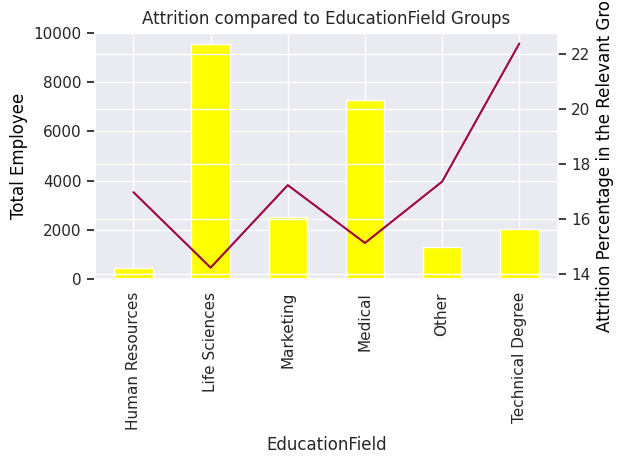

In [114]:
# Attrition compared to Education Field Graph
graph_df(x = 'EducationField', z = 90)

**Environment Satisfaction**

In [115]:
# Labeling environment satisfaction
table_df(x = 'EnvironmentSatisfaction')
df2['EnvironmentSatisfaction'] = df2['EnvironmentSatisfaction'].map({1:'Low', 2:'Medium',
                                                                     3:'High', 4:'Very High'})

In [116]:
# Environment & Attrition Table
table_df(x = 'EnvironmentSatisfaction')

,EnvironmentSatisfaction,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,High,7125,1048,14.708772,28.688749
1,Low,4512,874,19.370567,23.925541
2,Medium,4481,723,16.134791,19.791952
3,Very High,7021,1008,14.356929,27.593759


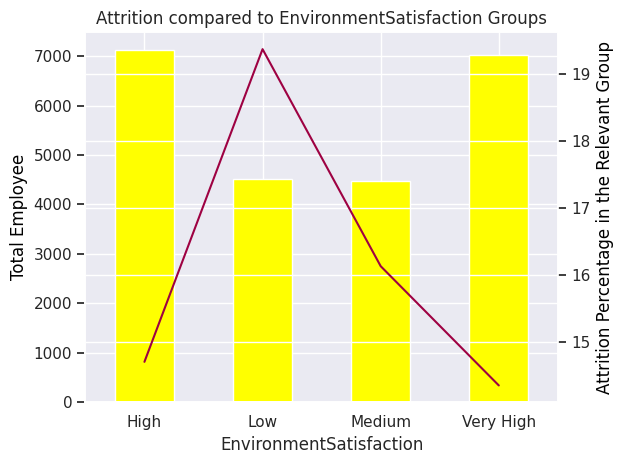

In [117]:
# Attrition compared to Environment Satisfaction Graph
graph_df(x = 'EnvironmentSatisfaction')

**Gender**

In [118]:
# Gender & Attrition Table
table_df(x = 'Gender')

,Gender,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Female,9257,1416,15.296532,38.762661
1,Male,13882,2237,16.114393,61.237339


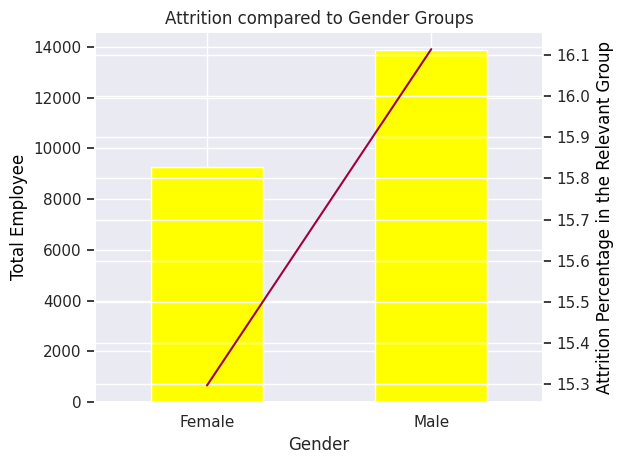

In [119]:
# Attrition compared to Gender Graph
graph_df(x = 'Gender')

**Male employees** are more likely to leave the company than **female employees**.

**Job Involvement**

In [120]:
# Labeling Job Involvement Groups
table_df(x = 'JobInvolvement')
df2['JobInvolvement'] = df2['JobInvolvement'].map({1:'Low', 2:'Medium',
                                                   3:'High', 4:'Very High'})

In [121]:
# Job Involvement & Attrition Table
table_df(x = 'JobInvolvement')

,JobInvolvement,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,High,15957,2306,14.451338,63.126198
1,Low,1299,311,23.941493,8.513551
2,Medium,5883,1036,17.610063,28.360252


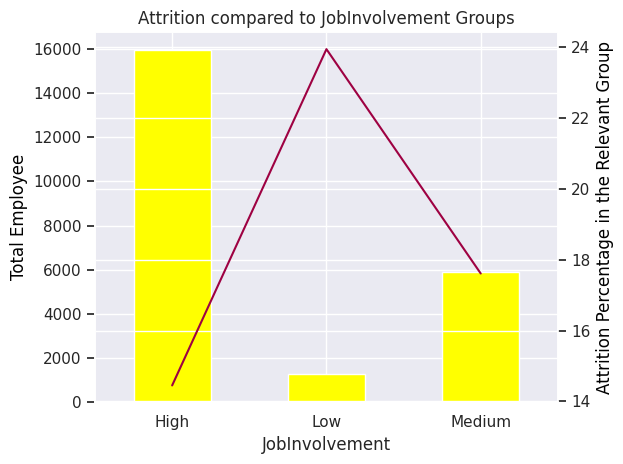

In [122]:
# Attrition compared to Job Involvement Graph
graph_df(x = 'JobInvolvement')

**Job Level**

In [123]:
# Labeling job levels
table_df(x = 'JobLevel')
df2['JobLevel'] = df2['JobLevel'].map({1:'Level-1', 2:'Level-2',
                                       3:'Level-3', 4:'Level-4', 5:'Level-5'})

In [124]:
# Job Level & Attrition Table
table_df(x = 'JobLevel')

,JobLevel,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Level-1,8527,1756,20.593409,48.070079
1,Level-2,8416,1070,12.713878,29.290994
2,Level-3,3436,523,15.221187,14.317000
3,Level-4,1679,215,12.805241,5.885574
4,Level-5,1081,89,8.233117,2.436354


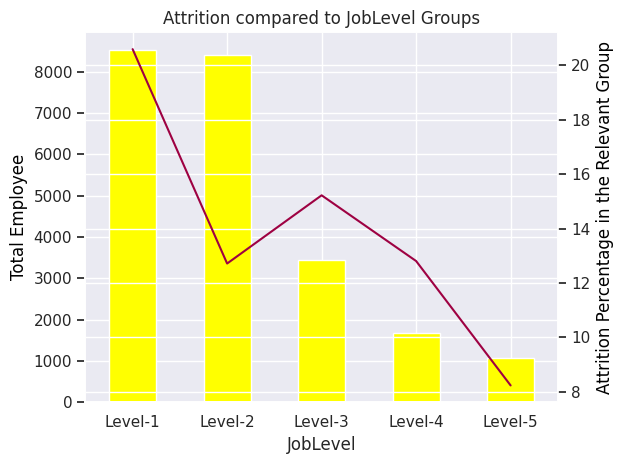

In [125]:
# Attrition compared to Job Level Graph
graph_df(x = 'JobLevel')

**Job Role**

In [126]:
# Job Role & Attrition Table
table_df(x = 'JobRole')

,JobRole,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Healthcare Representative,2072,289,13.947876,7.911306
1,Human Resources,835,148,17.724551,4.051465
2,Laboratory Technician,4097,748,18.257261,20.476321
3,Manager,1584,138,8.712121,3.777717
4,Manufacturing Director,2357,287,12.176496,7.856556
5,Research Director,1279,124,9.695074,3.394470
6,Research Scientist,4580,738,16.113537,20.202573
7,Sales Executive,5036,817,16.223193,22.365179
8,Sales Representative,1299,364,28.021555,9.964413


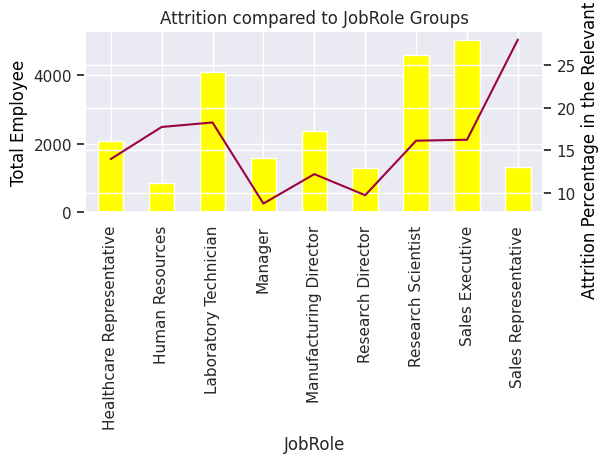

In [127]:
# Attrition compared to Job Role Graph
graph_df(x = 'JobRole', z = 90)

**Job Satisfaction**

In [128]:
# Labeling Job Role
table_df(x = 'JobSatisfaction')
df2['JobSatisfaction'] = df2['JobSatisfaction'].map({1:'Low', 2:'Medium',
                                                     3:'High', 4:'Very High'})

In [129]:
# Job Satisfaction & Attrition Table
table_df(x = 'JobSatisfaction')

,JobSatisfaction,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,High,7005,1156,16.502498,31.645223
1,Low,4551,873,19.182597,23.898166
2,Medium,4395,686,15.608646,18.779086
3,Very High,7188,938,13.049527,25.677525


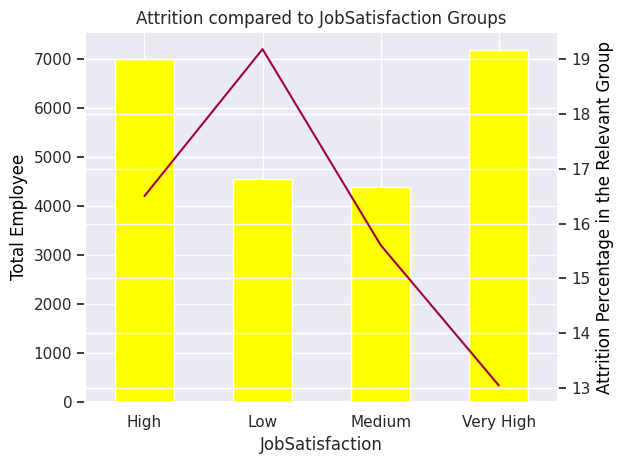

In [130]:
# Attrition compared to Job Satisfaction
graph_df(x = 'JobSatisfaction')

**Marital Status**

In [131]:
# Job Satisfaction & Attrition Table
table_df(x = 'MaritalStatus')

,MaritalStatus,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Divorced,5153,596,11.566078,16.315357
1,Married,10589,1405,13.268486,38.461538
2,Single,7397,1652,22.333378,45.223104


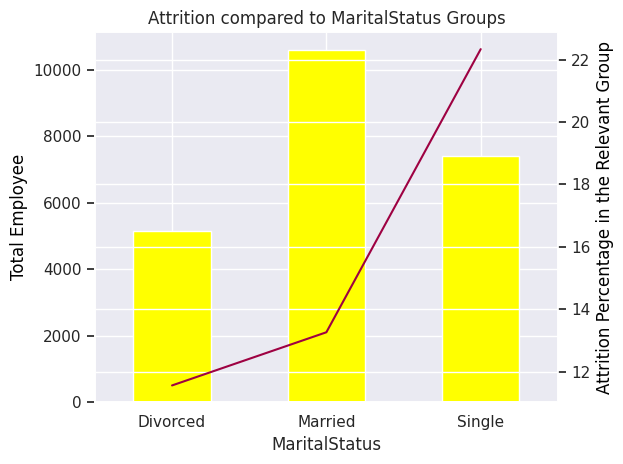

In [132]:
# Attrition compared to Job Satisfaction
graph_df(x = 'MaritalStatus')

**Monthly Income**

In [133]:
# Labeling Monthly Income Level
table_df(x = "MonthlyIncome")
bins = [1000, 2000, 3000, 4000, 5000, 7500, 9000, 11000, 15000, 20000]
group_names = ['1000-2000', '2000-3000', '3000-4000', '4000-5000', '5000-7500',
               '7500-9000', '9000-11000', '11000-15000', '15000-20000']
df2["MonthlyIncome"] = pd.cut(df2["MonthlyIncome"], bins, labels = group_names)

In [134]:
# Monthly Income & Attrition Table
table_df(x = "MonthlyIncome")

,MonthlyIncome,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,1000-2000,516,212,41.085271,5.803449
1,2000-3000,5675,1168,20.581498,31.973720
2,3000-4000,2357,295,12.515910,8.075554
3,4000-5000,3225,463,14.356589,12.674514
4,5000-7500,4874,659,13.520722,18.039967
5,7500-9000,1250,183,14.640000,5.009581
6,9000-11000,1848,282,15.259740,7.719682
7,11000-15000,1293,211,16.318639,5.776074
8,15000-20000,2101,180,8.567349,4.927457


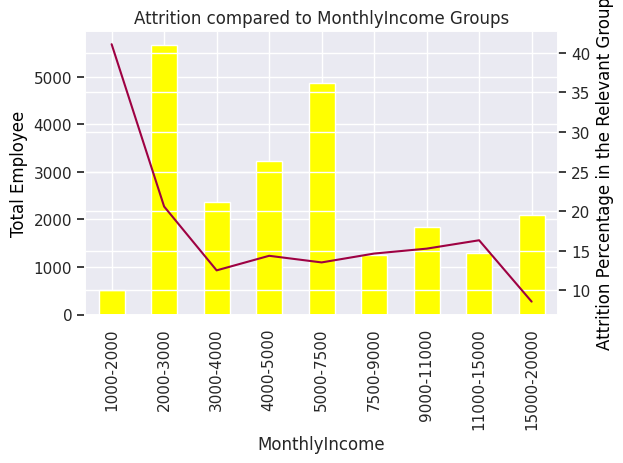

In [135]:
# Attrition compared to Monthly Income Level Graph
graph_df(x = "MonthlyIncome", z = 90)

**Numbers Companies Worked**

In [136]:
# Labeling Numbers Companied Worked Groups
table_df(x = 'NumCompaniesWorked')
bins = [0, 1, 2, 3, 4, 5, 10]
group_names = ['0', '1', '2', '3', '4', '5+']
df2['NumCompaniesWorked'] = pd.cut(df2['NumCompaniesWorked'], bins, labels = group_names,
                                        include_lowest = True, right = False)

In [137]:
# Numbers Companied Worked & Attrition Table
table_df(x = 'NumCompaniesWorked')

,NumCompaniesWorked,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,0,3138,446,14.212874,12.209143
1,1,8195,1317,16.070775,36.052560
2,2,2298,326,14.186249,8.924172
3,3,2489,364,14.624347,9.964413
4,4,2176,276,12.683824,7.555434
5,5+,4843,924,19.079083,25.294279


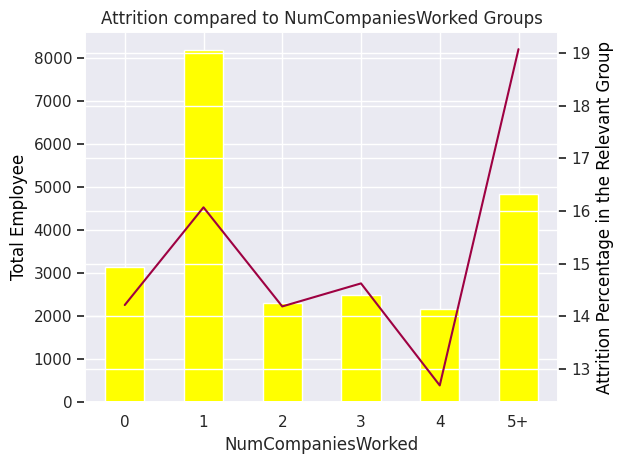

In [138]:
# Attrition compared to Numbers of Companies Worked Graph
graph_df(x = 'NumCompaniesWorked')

**Over Time**

In [139]:
# Numbers Companied Worked & Attrition Table
table_df(x = 'OverTime')

,OverTime,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,No,16590,2064,12.441230,56.501506
1,Yes,6549,1589,24.263246,43.498494


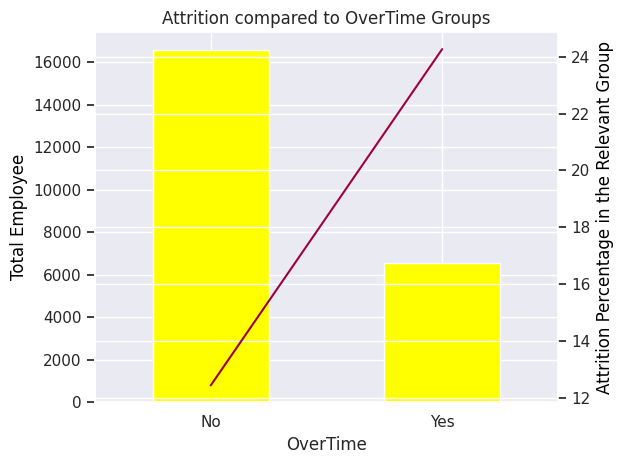

In [140]:
# Attrition compared to Numbers of Companies Worked Graph
graph_df(x = 'OverTime')

**Percent Salary Hike**

In [141]:
# Percent Salary Hike & Attrition Table
table_df(x = 'PercentSalaryHike')
bins = [10, 14, 18, 22, 25]
group_names = ['11-14', '15-18', '19-22', '23-25']
df2['PercentSalaryHike'] = pd.cut(df2['PercentSalaryHike'], bins, labels = group_names)

In [142]:
# Percent Salary Hike & Attrition Table
table_df(x = 'PercentSalaryHike')

,PercentSalaryHike,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,11-14,12873,2079,16.150082,56.912127
1,15-18,5501,863,15.688057,23.624418
2,19-22,3706,519,14.004317,14.207501
3,23-25,1059,192,18.130312,5.255954


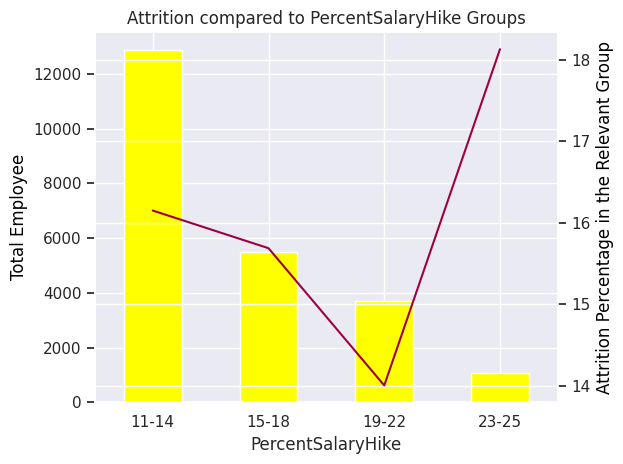

In [143]:
# Attrition compared to Percent Salary Hike
graph_df(x = 'PercentSalaryHike')

**Performance Rating**

In [144]:
# Performance Rating & Attrition Table
table_df(x = 'PerformanceRating')

,PerformanceRating,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,3,19545,3106,15.891532,85.026006
1,4,3594,547,15.219811,14.973994


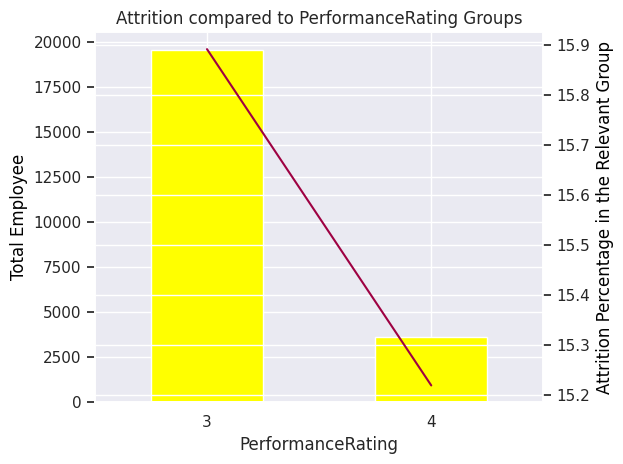

In [145]:
# Attrition compared to Performance Rating
graph_df(x = 'PerformanceRating')

**Relationship Satisfaction**

In [146]:
# Labeling Relationship Satisfaction Levels
table_df(x = 'RelationshipSatisfaction')
df2['RelationshipSatisfaction'] = df2['RelationshipSatisfaction'].map({1:'Low', 2:'Medium',
                                                                       3:'High', 4:'Very High'})

In [147]:
# Relationship & Attrition Table
table_df(x = 'RelationshipSatisfaction')

,RelationshipSatisfaction,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,High,7203,1185,16.451479,32.439091
1,Low,4319,762,17.642973,20.859567
2,Medium,4794,638,13.308302,17.465097
3,Very High,6823,1068,15.652939,29.236244


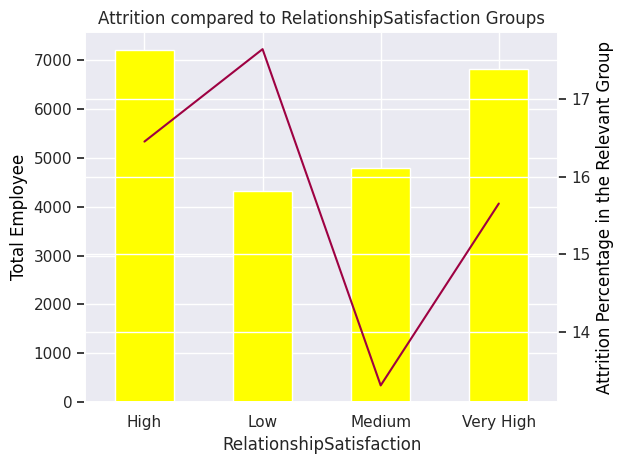

In [148]:
# Attrition compared to Relationship Satisfaction Graph
graph_df(x = 'RelationshipSatisfaction')

**Stock Option Level**

In [149]:
# Relationship & Attrition Table
table_df(x = 'StockOptionLevel')

,StockOptionLevel,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,0,9921,2123,21.399053,58.116616
1,1,9376,1035,11.038823,28.332877
2,2,2517,284,11.283274,7.774432
3,3,1325,211,15.924528,5.776074


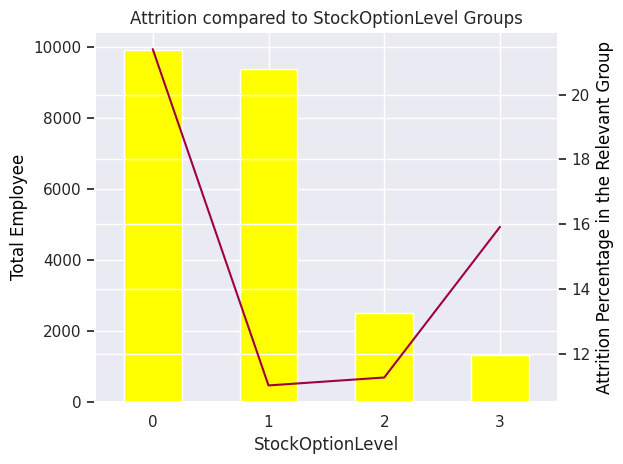

In [150]:
# Attrition compared to Stock Option Level Graph
graph_df(x = 'StockOptionLevel')

**Total Working Years**

In [151]:
# Total Working Years & Attrition Table
table_df(x = 'TotalWorkingYears')
bins = [0, 1, 5, 10, 15, 20, 40]
group_names = ['1', '2-5', '6-10', '11-15', '16-20', '20+']
df2['TotalWorkingYears'] = pd.cut(df2['TotalWorkingYears'], bins, labels = group_names,
                                  include_lowest = True)

In [152]:
# Total Working Years & Attrition Table
table_df(x = 'TotalWorkingYears')

,TotalWorkingYears,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,1,1465,473,32.286689,12.948262
1,2-5,3502,637,18.189606,17.437722
2,6-10,9585,1456,15.190402,39.857651
3,11-15,2978,374,12.558764,10.238160
4,16-20,2365,328,13.868922,8.978921
5,20+,3244,385,11.868064,10.539283


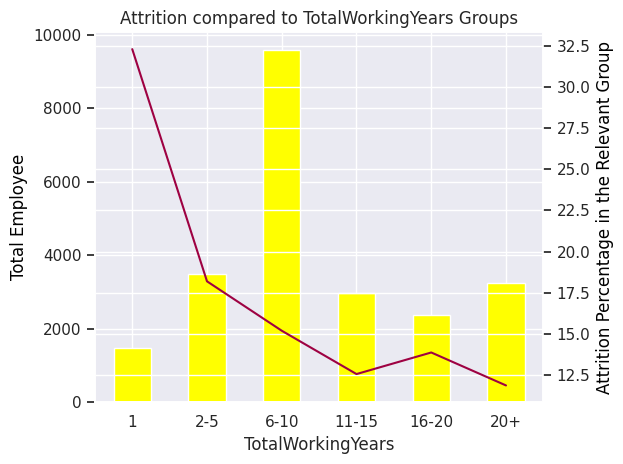

In [153]:
graph_df(x = 'TotalWorkingYears')

**Training Times Last Year**

In [154]:
# Training Times Last Year & Attrition Table
table_df(x = 'TrainingTimesLastYear')

,TrainingTimesLastYear,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,0,848,206,24.292453,5.639201
1,1,1120,175,15.625000,4.790583
2,2,8625,1438,16.672464,39.364906
3,3,7707,1117,14.493318,30.577607
4,4,1945,395,20.308483,10.813030
5,5,1858,188,10.118407,5.146455
6,6,1036,134,12.934363,3.668218


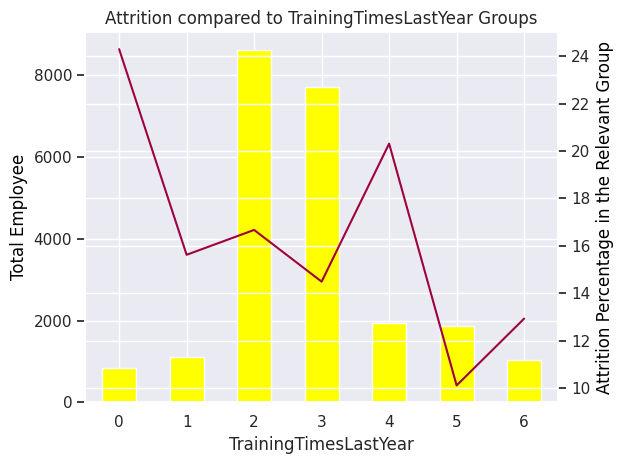

In [155]:
# Attrition compared to Training Times Last Year Graph
graph_df(x = 'TrainingTimesLastYear')

**Work Life Balance**

In [156]:
# Labeling Work Life Balance Groups
table_df(x = 'WorkLifeBalance')
df2['WorkLifeBalance'] = df2['WorkLifeBalance'].map({1:'Bad', 2:'Good',
                                                     3:'Better', 4:'Best'})

In [157]:
# Work Life Balance & Attrition Table
table_df(x = 'WorkLifeBalance')

,WorkLifeBalance,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Bad,1251,243,19.424460,6.652067
1,Best,2404,361,15.016639,9.882289
2,Better,14073,2164,15.376963,59.238982
3,Good,5411,885,16.355572,24.226663


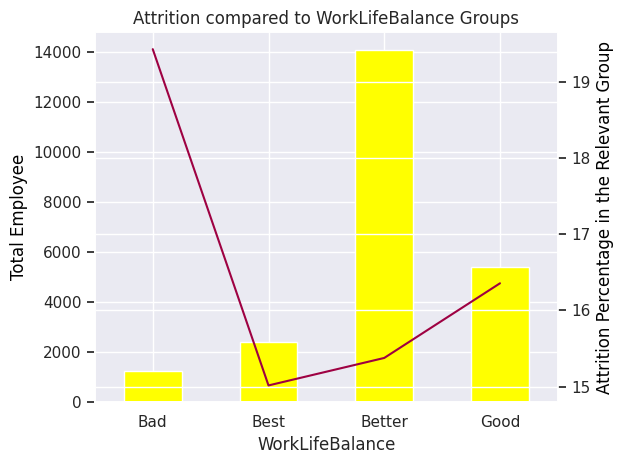

In [158]:
# Attrition compared to Work Life Balance Graph
graph_df(x = 'WorkLifeBalance')

**Years at Company**

In [159]:
# Labeling Years at Company Groups
table_df(x = 'YearsAtCompany')
bins = [0, 1, 5, 10, 40]
group_names = ['1', '2-5', '6-10', '10+']
df2['YearsAtCompany'] = pd.cut(df2['YearsAtCompany'], bins, labels = group_names,
                               include_lowest = True)

In [160]:
# Years at Company & Attrition Table
table_df(x = 'YearsAtCompany')

,YearsAtCompany,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,1,3408,813,23.855634,22.255680
1,2-5,8799,1389,15.785885,38.023542
2,6-10,7045,975,13.839603,26.690391
3,10+,3887,476,12.245948,13.030386


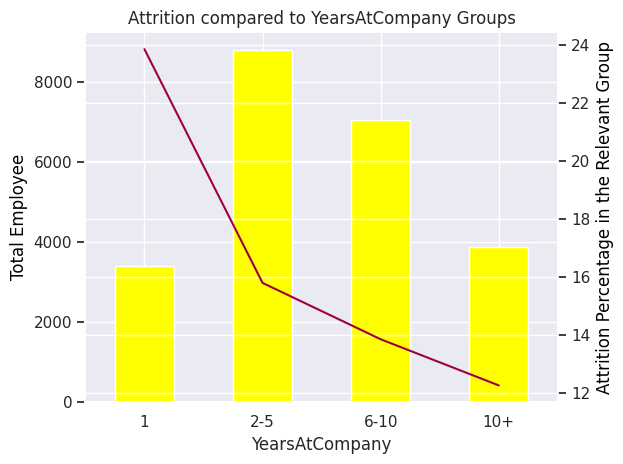

In [161]:
# Years at Company & Attrition Graph
graph_df(x = 'YearsAtCompany')

**Years in Current Role**

In [162]:
# Labeling Years in Current Role Groups
table_df(x = 'YearsInCurrentRole')
bins = [0, 1, 4, 6, 7, 10, 18]
group_names = ['1', '2-4', '5-6', '7', '8-10', '10+']
df2['YearsInCurrentRole'] = pd.cut(df2['YearsInCurrentRole'], bins, labels = group_names,
                                   include_lowest = True)

In [163]:
# Years at Company & Attrition Table
table_df(x = 'YearsAtCompany')

,YearsAtCompany,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,1,3408,813,23.855634,22.255680
1,2-5,8799,1389,15.785885,38.023542
2,6-10,7045,975,13.839603,26.690391
3,10+,3887,476,12.245948,13.030386


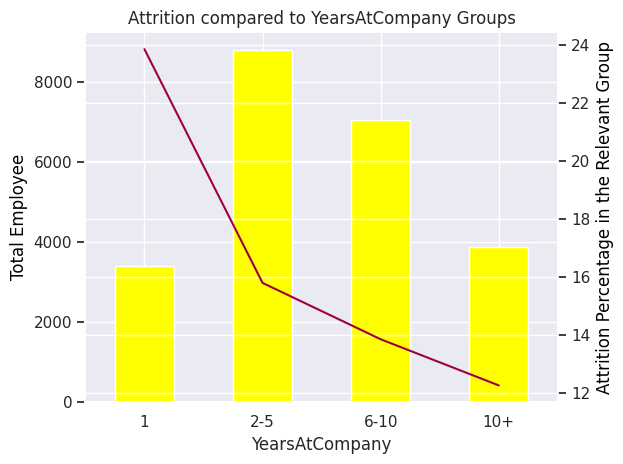

In [164]:
# Years in Current Role & Attrition Graph
graph_df(x = 'YearsAtCompany')

**Years Since Last Promotion**

In [165]:
# Labeling Years in Current Role Groups
table_df(x = 'YearsSinceLastPromotion')
bins = [0, 1, 2, 3, 4, 7, 8, 16]
group_names = ['0', '1', '2', '3', '4-6', '7', '8+']
df2['YearsSinceLastPromotion'] = pd.cut(df2['YearsSinceLastPromotion'], bins, labels = group_names,
                                        include_lowest = True, right = False)

In [166]:
# Years Since Last Promotion & Attrition Table
table_df(x = 'YearsSinceLastPromotion')

,YearsSinceLastPromotion,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,0,9159,1554,16.966918,42.540378
1,1,5612,841,14.985745,23.022174
2,2,2509,409,16.301315,11.196277
3,3,831,123,14.801444,3.367096
4,4-6,2155,271,12.575406,7.418560
5,7,1204,217,18.023256,5.940323
6,8+,1669,238,14.260036,6.515193


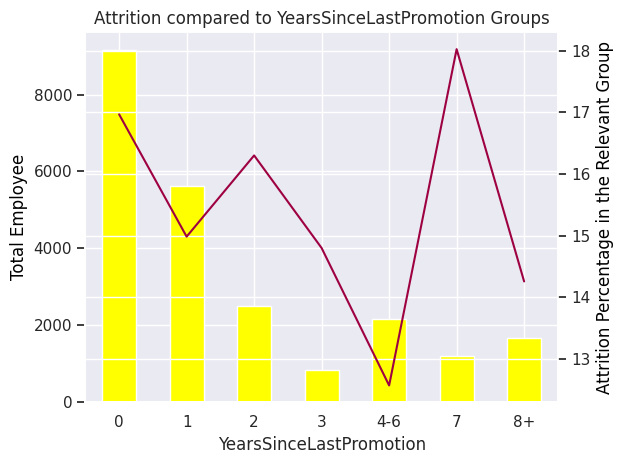

In [167]:
# Years Since Last Promotion & Attrition Graph
graph_df(x = 'YearsSinceLastPromotion')

**Years with Current Manager**

In [168]:
# Labeling Years with Current Manager Groups
table_df(x = 'YearsWithCurrManager')
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 18]
group_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10+']
df2['YearsWithCurrManager'] = pd.cut(df2['YearsWithCurrManager'], bins, labels = group_names,
                                     include_lowest = True, right = False)

In [169]:
# Years with Current Manager & Attrition Table
table_df(x = 'YearsWithCurrManager')

,YearsWithCurrManager,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,0,4139,939,22.686639,25.704900
1,1,1198,148,12.353923,4.051465
2,2,5397,785,14.545118,21.489187
3,3,2225,371,16.674157,10.156036
4,4,1546,220,14.230272,6.022447
5,5,484,101,20.867769,2.764851
6,6,454,74,16.299559,2.025732
7,7,3412,495,14.507620,13.550506
8,8,1677,228,13.595707,6.241445
9,9,1030,117,11.359223,3.202847


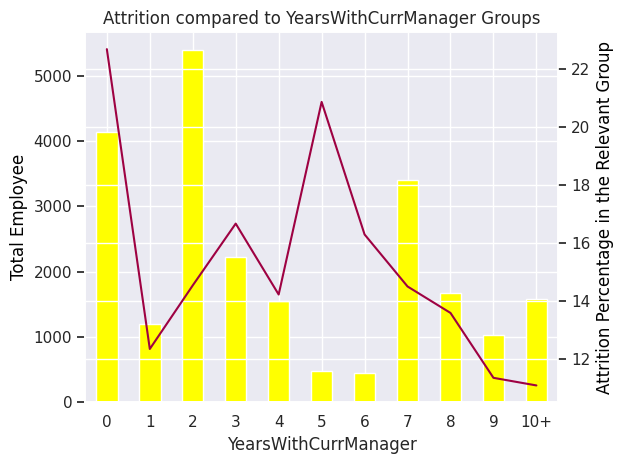

In [170]:
# Years with Current Manager & Attrition Graph
graph_df(x = 'YearsWithCurrManager')

In [172]:
df2.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,(36-60),Travel_Rarely,1102,Sales,1-3,College,Life Sciences,1,Medium,Female,...,Low,0,6-10,0,Bad,6-10,2-4,0,5,1
1,(36-60),Travel_Rarely,1102,Sales,1-3,College,Life Sciences,7,Medium,Female,...,Low,0,6-10,0,Bad,6-10,2-4,0,5,1
2,(36-60),Travel_Rarely,1102,Sales,1-3,College,Life Sciences,8,Medium,Female,...,Low,0,6-10,0,Bad,6-10,2-4,0,5,1
3,(36-60),Travel_Rarely,1102,Sales,1-3,College,Life Sciences,9,Medium,Female,...,Low,0,6-10,0,Bad,6-10,2-4,0,5,1
4,(36-60),Travel_Rarely,1102,Sales,1-3,College,Life Sciences,10,Very High,Female,...,High,3,20+,2,Better,2-5,1,0,2,1


### Feature/Variable Relationships:

#### Correlation Matrix

In [173]:
dff.drop(columns=['MonthlyRate', 'RelationshipSatisfaction','WorkLifeBalance'], inplace=True)

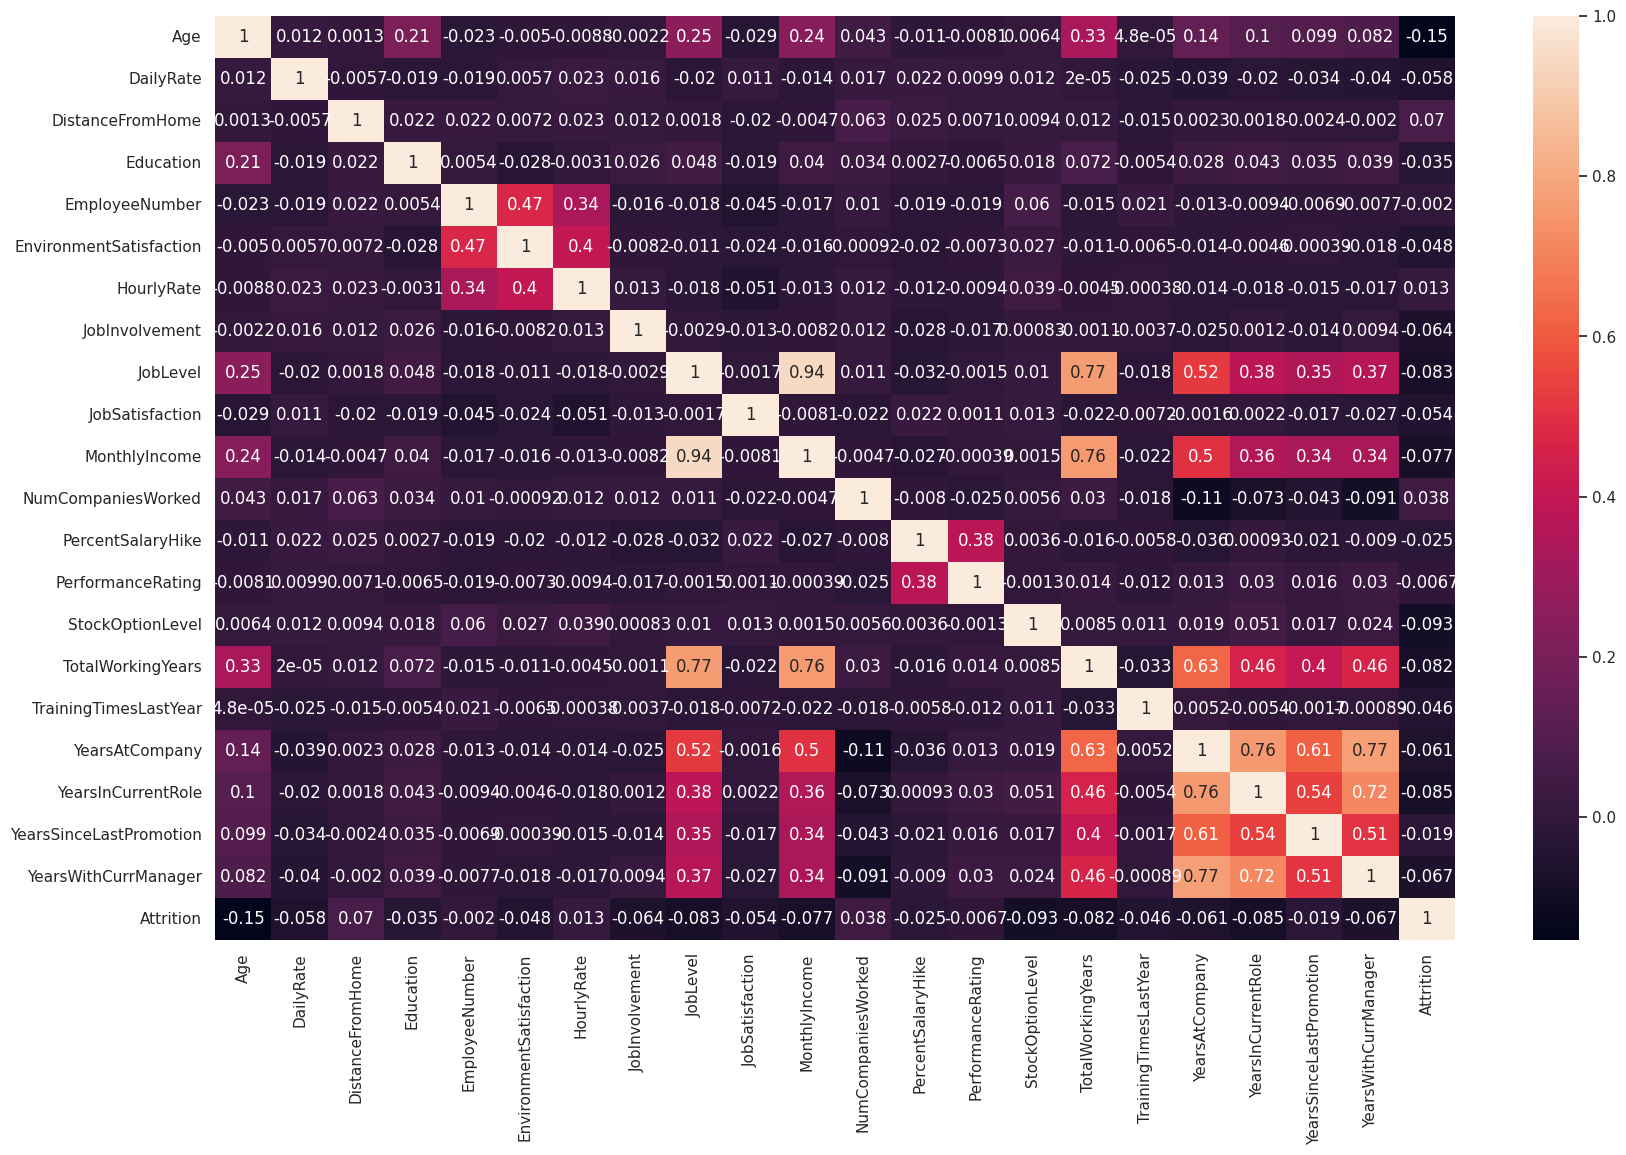

In [174]:
numeric_df1 = dff.select_dtypes(include=['int64', 'float64'])
corr_matrix1 = numeric_df1.corr()

f, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(corr_matrix1, vmax=1, annot=True)
plt.show()

## Hypothesis Testing (Examining Attrition in Gender throughout the company)

### 1. Selecting appropriate test

In [175]:
# Gender & Attrition Table
table_df(x = 'Gender')

,Gender,Total Employee,Attrition Number,% of Attrition in the Relevant Group,% of Attrition in the Company
0,Female,9257,1416,15.296532,38.762661
1,Male,13882,2237,16.114393,61.237339


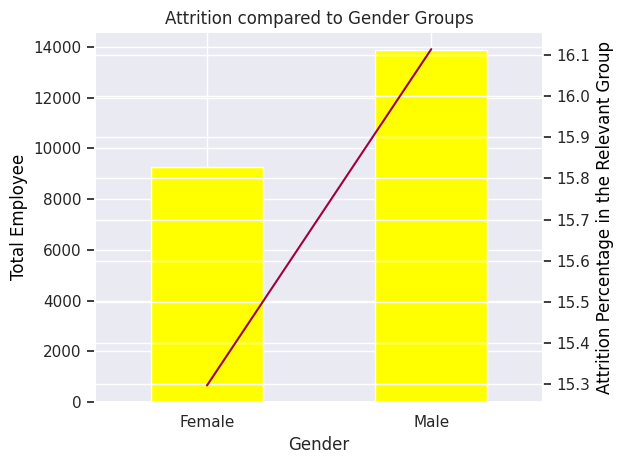

In [176]:
# Attrition compared to Gender Graph
graph_df(x = 'Gender')

### 2. The Null and Alternate Hypotheses

As observed above, it is obvious that male attrition is more than female's attrition but is the difference significant? Here is the important point to define the null and alternative hypothesis:

In the context of provided information, the alternative hypothesis assumes that male attrition is pervasive enough to be a factor in attrition throughout the company.

Null Hypothesis: There is no difference in the proportion of attrition for male and female employees in the company.

$$H_0: \hat p_{male\_attrition} - \hat p_{female\_attrition} = 0$$

Alternative Hypothesis: There is a significant difference in the proportion of attrition for male and female employees in the company.

$$H_a: {\hat p_{male\_attrition}} - {\hat p_{female\_attrition}} \neq 0$$
Significance Level: 95% Confidence:

### 3. The Frequentist Statistical Approach

In [177]:
# Assign female and  male into variables
female = df2[df2['Gender'] == 'Female']
male = df2[df2['Gender'] == 'Male']

# Find the mean for female and male employees attrition
female_attrition_mean = female['Attrition'].mean()
male_attrition_mean = male['Attrition'].mean()
print ('Female attrition mean: {}'.format(female_attrition_mean))
print ('Male attrition mean: {}'.format(male_attrition_mean))

# Find the difference of female and male employees attrition
diff_mean = male_attrition_mean - female_attrition_mean
print ('Difference of mean between male and female employees attrition: {}'.format(diff_mean))

Female attrition mean: 0.15296532353894352
Male attrition mean: 0.16114392738798444
Difference of mean between male and female employees attrition: 0.008178603849040927


**z-score**

In [178]:
# Compute z-score
male_attrition = np.sum(male['Attrition'])
female_attrition = np.sum(female['Attrition'])
male_ln = len(male)
female_ln = len(female)
phat = (male_attrition + female_attrition) / (male_ln + female_ln)
z = (diff_mean) / np.sqrt(phat * (1 - phat) * (( 1/ float(male_ln)) + (1/float(female_ln))))
print ('z score:{}'.format(z))

z score:1.6715771749032031


**p-value**

In [179]:
# Compute p-value
p = stats.norm.cdf(-z)*2
print ('p-value:{}'.format(p))

p-value:0.09460772878056337


**Margin of error**

In [180]:
# Compute margin of error
moe = 1.96 * np.sqrt(phat * (1 - phat) * (( 1/ float(male_ln)) + (1/float(female_ln))))
print("Margin of Error: {}".format(moe))

Margin of Error: 0.009589783699366724


**Confidence Interval**

In [181]:
# Compute confidence interval
ci = diff_mean + np.array([-1, 1]) * moe
print("Confidence interval: {}".format(ci))

Confidence interval: [-0.00141118  0.01776839]
